In [54]:
import os
import sys
sys.path.append(os.path.abspath('../scripts'))
fig_path      = '../figures/'
data_path     = '../data/'

In [55]:
import netCDF4 as nc
import numpy as np
import xarray as xr
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd 
import seaborn as sns
import cmocean as cmo
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec
from proj_utils import *
from mapping_utils import *
from plotting_utils import *

## (1) Open WSC file and SLP

In [56]:
ds_wsc = xr.open_dataset(data_path + '/wsc.nc')
ds_wsc['longitude'] = ds_wsc.longitude
ds_wsc = rmv_clm(ds_wsc)
ds_wsc = seasonal_detrend(ds_wsc)

In [57]:
ds_slp = xr.open_dataset(data_path + 'north_atlantic_slp.nc')

ds_slp = ds_slp.sel(expver = slice(0,1)).squeeze()
ds_slp = ds_slp.drop_vars('expver')
ds_slp = ds_slp.sel(time = slice('1993-01-01','2023-12-01'))
ds_slp = ds_slp.sortby(ds_slp.latitude)

ds_slp = seasonal_detrend(ds_slp)

In [58]:
alt     = pd.read_csv(data_path + 'gsi_altimetry_locations.csv')

## (2) Calc SLP EOFS (full period) and unscaled PCs

In [59]:
eofs_full, pcs_full, per_var_full, eigs_full = calc_eofs(ds_slp['msl'], num_modes=4)

/Users/lillienders/gs-var/scripts/proj_utils.py:413: RuntimeWarning: invalid value encountered in sqrt
  wgts = np.sqrt(coslat)[..., np.newaxis]


In [60]:
pcs_unscaled = pcs_full*np.sqrt(eigs_full[:4])
nao_unscaled = -pcs_unscaled[:,0]
eap_unscaled = -pcs_unscaled[:,1]

In [61]:
# --- NAO AND EAP SPATIAL PATTERNS FOR WHOLE PERIOD (92-23) ---
nao_sp = xr.open_dataarray(data_path + 'nao_era5_spatial_pattern.nc')
eap_sp = xr.open_dataarray(data_path + 'eap_era5_spatial_pattern.nc')

## (3) Do full time series regressions

In [62]:
reg_nao_wsc   = linregress_spatial(nao_unscaled, ds_wsc.wsc)
reg_eap_wsc   = linregress_spatial(eap_unscaled, ds_wsc.wsc)

## (4) Plot full time series regressions

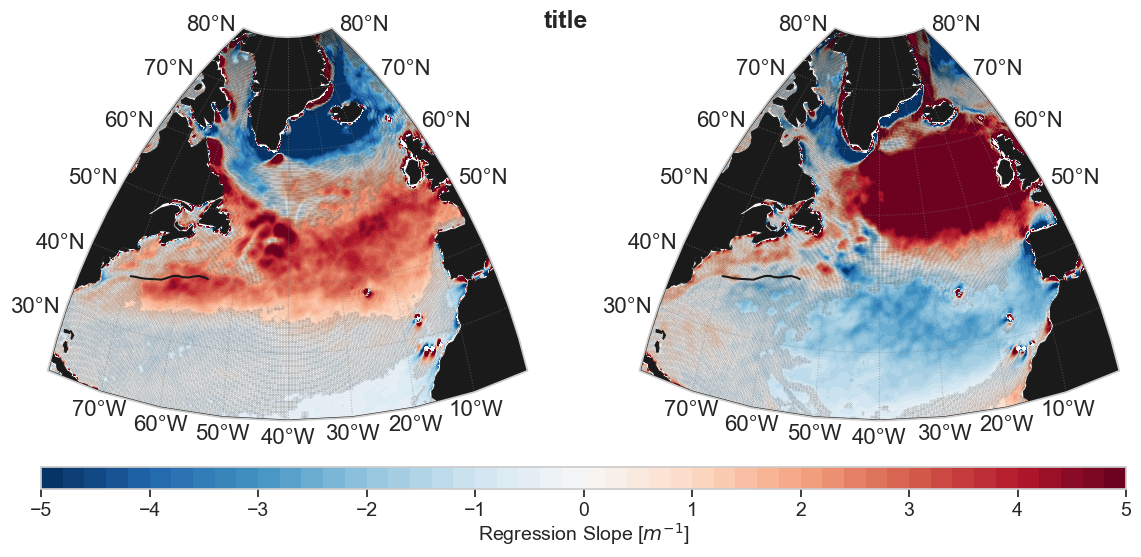

In [63]:
style   = sns.set_style("whitegrid")

fig = plt.figure(figsize=(14, 6))
gs  = gridspec.GridSpec(1, 2, figure=fig)

# -------------------------------------------
# ---- MODE ONE/WSC REGRESSION --------------
# -------------------------------------------
tit = fig.suptitle('title',fontsize = 18,fontweight = 'bold', y = 0.91)

ax_left = fig.add_subplot(1, 2, 1, projection=ccrs.Orthographic(central_longitude=-40, central_latitude=35))

var_to_plot = reg_nao_wsc*100
cmax = 5
var_to_plot.slope.data[var_to_plot.slope.data > cmax] = cmax
var_to_plot.slope.data[var_to_plot.slope.data < -cmax] = -cmax

bbox = [-80, 0, 20, 80]
fig, ax_left, _ = init_orthomap(bboxplot=bbox, ax=ax_left)
ax_left = add_coast_grid(ax_left, bbox, fill_color='k', line_color='k')

levels = np.linspace(-cmax, cmax, 51)

colorplot = ax_left.contourf(
    var_to_plot.longitude, var_to_plot.latitude, var_to_plot.slope,
    transform=proj, levels=levels, cmap='RdBu_r', zorder=0
)

xorg = var_to_plot.longitude.data
yorg = var_to_plot.latitude.data
nlon = len(xorg)
nlat = len(yorg)
xdata = np.reshape(np.tile(xorg, nlat), var_to_plot.slope.shape)
ydata = np.reshape(np.repeat(yorg, nlon), var_to_plot.slope.shape)
xpoints = xdata[var_to_plot.p_value > 0.05]
ypoints = ydata[var_to_plot.p_value > 0.05]

ax_left.scatter(xpoints, ypoints, s=0.2, c='k', marker='.', alpha=0.3,transform=proj)
ax_left.plot(alt['longitude'], alt['latitude'], color='k', transform = proj)


# -------------------------------------------
# ---- MODE TWO/WSC REGRESSION --------------
# -------------------------------------------

ax_right = fig.add_subplot(1, 2, 2, projection=ccrs.Orthographic(central_longitude=-40, central_latitude=35))

var_to_plot = reg_eap_wsc*100
cmax = 5
var_to_plot.slope.data[var_to_plot.slope.data > cmax] = cmax
var_to_plot.slope.data[var_to_plot.slope.data < -cmax] = -cmax

bbox = [-80, 0, 20, 80]
fig, ax_right, _ = init_orthomap(bboxplot=bbox, ax=ax_right)
ax_right = add_coast_grid(ax_right, bbox, fill_color='k', line_color='k')

levels = np.linspace(-cmax, cmax, 51)

colorplot = ax_right.contourf(
    var_to_plot.longitude, var_to_plot.latitude, var_to_plot.slope,
    transform=proj, levels=levels, cmap='RdBu_r', zorder=0
)

xorg = var_to_plot.longitude.data
yorg = var_to_plot.latitude.data
nlon = len(xorg)
nlat = len(yorg)
xdata = np.reshape(np.tile(xorg, nlat), var_to_plot.slope.shape)
ydata = np.reshape(np.repeat(yorg, nlon), var_to_plot.slope.shape)
xpoints = xdata[var_to_plot.p_value > 0.05]
ypoints = ydata[var_to_plot.p_value > 0.05]

ax_right.scatter(xpoints, ypoints, s=0.2, c='k', marker='.', alpha=0.3,transform=proj)
ax_right.plot(alt['longitude'], alt['latitude'], color='k', transform = proj)

cbar = fig.colorbar(
    colorplot, ax=[ax_left, ax_right], fraction=0.05,aspect=50, orientation='horizontal',
    ticks=np.linspace(-5, 5, 11), pad=0.1
)
cbar.ax.tick_params(labelsize=14)
cbar.set_label('Regression Slope [$m^{-1}$]', size=14, labelpad=1)


In [ ]:
## (5) Now for each window
window_sz = 48
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    for c in range(len(ds_slp.time)-(window_sz)):
    #for c in range(10):
        # --- Slice SLP ---
        slp_temp = ds_slp['msl'].sel(time = slice(ds_slp['msl'].time[c].data, ds_slp['msl'].time[c+window_sz].data))

        # --- Slice WSC --- 
        wsc_temp = ds_wsc['wsc'].sel(time = slice(ds_wsc['wsc'].time[c].data, ds_wsc['wsc'].time[c+window_sz].data))
        
        # --- Calculate modes ---
        eofs_temp, pcs_temp, per_var_temp, eigs_temp = calc_eofs(slp_temp, num_modes=4)
        mode_one_temp = eofs_temp[0,:,:]
        mode_two_temp = eofs_temp[1,:,:]

        pcs_unscaled = pcs_temp*np.sqrt(eigs_temp[:4])
        mode_one_unscaled = pcs_unscaled[:,0]
        mode_two_unscaled = pcs_unscaled[:,1]
        
        # --- Correct the sign of the modes ---
        corr_nao_temp = xr.corr(nao_sp,eofs_temp[0,:,:])
        corr_eap_temp = xr.corr(nao_sp,eofs_temp[1,:,:])
        
        if abs(corr_nao_temp) > abs(corr_eap_temp):
            sign_nao = xr.corr(nao_sp,eofs_temp[0,:,:])
            sign_eap = xr.corr(eap_sp,eofs_temp[1,:,:])
            if sign_nao < 0:
                mode_one_unscaled = - mode_one_unscaled
            if sign_eap < 0 :
                mode_two_unscaled = - mode_two_unscaled
            reg_nao_wsc   = linregress_spatial(mode_one_unscaled, wsc_temp)
            reg_eap_wsc   = linregress_spatial(mode_two_unscaled, wsc_temp)
        else:
            sign_nao = xr.corr(nao_sp,eofs_temp[1,:,:])
            sign_eap = xr.corr(eap_sp,eofs_temp[0,:,:])
            if sign_nao < 0:
                mode_two_unscaled = - mode_two_unscaled
            if sign_eap < 0 :
                mode_one_unscaled = - mode_one_unscaled
            reg_nao_wsc   = linregress_spatial(mode_two_unscaled, wsc_temp)
            reg_eap_wsc   = linregress_spatial(mode_one_unscaled, wsc_temp)

        # --- PLOT ---
        style   = sns.set_style("whitegrid")
        
        fig = plt.figure(figsize=(14, 6))
        gs  = gridspec.GridSpec(1, 2, figure=fig)
        tit = fig.suptitle(str(ds_slp.time[c].dt.year.data) + '-' + str(ds_slp.time[c].dt.month.data).zfill(2) 
                           +  ' to ' + str(ds_slp.time[c + window_sz].dt.year.data) + '-' 
                           + str(ds_slp.time[c + window_sz].dt.month.data).zfill(2),
                           fontsize = 18,fontweight = 'bold', y = 0.95)
        
        # -------------------------------------------
        # ---- MODE ONE/WSC REGRESSION --------------
        # -------------------------------------------
        
        ax_left = fig.add_subplot(1, 2, 1, projection=ccrs.Orthographic(central_longitude=-40, central_latitude=35))
        
        var_to_plot = reg_nao_wsc*100
        cmax = 5
        var_to_plot.slope.data[var_to_plot.slope.data > cmax] = cmax
        var_to_plot.slope.data[var_to_plot.slope.data < -cmax] = -cmax
        
        bbox = [-80, 0, 20, 80]
        fig, ax_left, _ = init_orthomap(bboxplot=bbox, ax=ax_left)
        ax_left = add_coast_grid(ax_left, bbox, fill_color='k', line_color='k')
        
        levels = np.linspace(-cmax, cmax, 51)
        
        colorplot = ax_left.contourf(
            var_to_plot.longitude, var_to_plot.latitude, var_to_plot.slope,
            transform=proj, levels=levels, cmap='RdBu_r', zorder=0
        )
        
        xorg = var_to_plot.longitude.data
        yorg = var_to_plot.latitude.data
        nlon = len(xorg)
        nlat = len(yorg)
        xdata = np.reshape(np.tile(xorg, nlat), var_to_plot.slope.shape)
        ydata = np.reshape(np.repeat(yorg, nlon), var_to_plot.slope.shape)
        xpoints = xdata[var_to_plot.p_value > 0.05]
        ypoints = ydata[var_to_plot.p_value > 0.05]
        
        ax_left.scatter(xpoints, ypoints, s=0.2, c='k', marker='.', alpha=0.3,transform=proj)
        ax_left.plot(alt['longitude'], alt['latitude'], color='k', transform = proj)
        
        
        # -------------------------------------------
        # ---- MODE TWO/WSC REGRESSION --------------
        # -------------------------------------------
        
        ax_right = fig.add_subplot(1, 2, 2, projection=ccrs.Orthographic(central_longitude=-40, central_latitude=35))
        
        var_to_plot = reg_eap_wsc*100
        cmax = 5
        var_to_plot.slope.data[var_to_plot.slope.data > cmax] = cmax
        var_to_plot.slope.data[var_to_plot.slope.data < -cmax] = -cmax
        
        bbox = [-80, 0, 20, 80]
        fig, ax_right, _ = init_orthomap(bboxplot=bbox, ax=ax_right)
        ax_right = add_coast_grid(ax_right, bbox, fill_color='k', line_color='k')
        
        levels = np.linspace(-cmax, cmax, 51)
        
        colorplot = ax_right.contourf(
            var_to_plot.longitude, var_to_plot.latitude, var_to_plot.slope,
            transform=proj, levels=levels, cmap='RdBu_r', zorder=0
        )
        
        xorg = var_to_plot.longitude.data
        yorg = var_to_plot.latitude.data
        nlon = len(xorg)
        nlat = len(yorg)
        xdata = np.reshape(np.tile(xorg, nlat), var_to_plot.slope.shape)
        ydata = np.reshape(np.repeat(yorg, nlon), var_to_plot.slope.shape)
        xpoints = xdata[var_to_plot.p_value > 0.05]
        ypoints = ydata[var_to_plot.p_value > 0.05]
        
        ax_right.scatter(xpoints, ypoints, s=0.2, c='k', marker='.', alpha=0.3,transform=proj)
        ax_right.plot(alt['longitude'], alt['latitude'], color='k', transform = proj)
        
        cbar = fig.colorbar(
            colorplot, ax=[ax_left, ax_right], fraction=0.05,aspect=50, orientation='horizontal',
            ticks=np.linspace(-5, 5, 11), pad=0.1
        )
        cbar.ax.tick_params(labelsize=14)
        cbar.set_label('Regression Slope [$m^{-1}$]', size=14, labelpad=1)
        plt.savefig(fig_path + 'wsc_regs/wsc_regs_' + str(ds_slp.time[c].dt.year.data) + str(ds_slp.time[c].dt.month.data).zfill(2) + '.png', format='png', bbox_inches="tight",dpi=500)
        plt.close()